In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import tifffile as tiff

from pyvis.network import Network

from skimage.morphology import skeletonize
from skimage.util import invert
from skimage import io

from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle

from scipy.interpolate import griddata


#notes
#consider multiple edges/self loops

In [2]:
#load files and append HH12,13 (saved separately due to long execution time)

conditions = ["control nuclei","10um nuclei","20um nuclei"]
conditions_brendan = ["10um", "30um", "50um"]

drug_name = "mmp brendan"
nodes_list_brendan=pickle.load(open(f"results/skeleton/drug_results/nodes_list_{drug_name}.txt","rb"))
adj_list_brendan=pickle.load(open(f"results/skeleton/drug_results/adj_list_{drug_name}.txt","rb"))

drug_name = "mmp hh8+24hr"
nodes_list=pickle.load(open(f"results/skeleton/drug_results/nodes_list_{drug_name}.txt","rb"))
adj_list=pickle.load(open(f"results/skeleton/drug_results/adj_list_{drug_name}.txt","rb"))


In [3]:
def count_neighbours(adj,min=0,max=999):
    adj = adj[adj>0]
    neighbours = adj.count()
    neighbours = neighbours[neighbours>=min]
    neighbours = neighbours[neighbours<=max]
    return neighbours

In [4]:
def return_neighbours(adj):
    adj = adj[adj>0]
    neighbours = adj.count()
    neighbours = pd.Series.value_counts(neighbours)
    return neighbours

In [5]:
def gen_networkx_graph(nodes,adj):
    G = nx.Graph()
    for i in nodes.index:
        node = nodes.loc[i]
        #G.add_node(i)#,weight=node["weight"])
        G.add_nodes_from([(i, {"x": int(node["x"]), "y": int(node["y"]), "weight":float(node["weight"])})])
    for i in adj.index:
        for j in adj.columns:
            weight = adj.loc[i,j]
            if weight>0:
                G.add_edge(i,j,weight=weight)
    #nx.draw(G, with_labels=True)
    return G

In [6]:
def set_up_df(nodes_list,adj_list,conditions):

    properties = ["Number of Nodes","Mean Edge Length","Mean Node Weight","Average Degree of Non-Isolated Nodes","Number of Basis Cycles","Number of Components","Average Clustering","Average Shortest Path","Number of Isolated Nodes","Number of Components, Excluding Isolated Nodes","Proportion of Isolated Nodes"]

    #2d datastructure
    df = pd.DataFrame(index=properties, columns=conditions)

    for i in range(len(conditions)):
        cond=conditions[i]
        print(f"Condition is: {cond}")

        nodes = nodes_list[i]
        adj = adj_list[i]

        adj = pd.DataFrame(adj)
        nodes = pd.DataFrame(nodes)

        df.loc["Number of Nodes",cond] = len(nodes)
        df.loc["Mean Edge Length",cond] = adj.values[adj.values>0].mean()
        df.loc["Mean Node Weight",cond] = np.mean(nodes["weight"])
        df.loc["Average Degree of Non-Isolated Nodes",cond] = count_neighbours(adj,min=1).mean()
        df.loc["Number of Isolated Nodes",cond] = np.array([count_neighbours(adj,min=0,max=100)==0]).sum()

        G=gen_networkx_graph(nodes,adj)
        print(f"Network generation complete\n")


        largest_cc = max(nx.connected_components(G), key=len)
        G_comp = G.subgraph(largest_cc).copy()


        df.loc["Number of Basis Cycles",cond] = len(sorted(nx.cycle_basis(G)))
        df.loc["Number of Components",cond] = len(sorted(nx.connected_components(G)))
        df.loc["Average Clustering",cond] = nx.average_clustering(G)
        df.loc["Average Shortest Path",cond] = nx.average_shortest_path_length(G_comp, weight='weight') #average shortest path of the largest component


        df.loc["Number of Components, Excluding Isolated Nodes",cond] = df.loc["Number of Components",cond] - df.loc["Number of Isolated Nodes",cond]
        df.loc["Proportion of Isolated Nodes", cond] = df.loc["Number of Isolated Nodes",cond] / df.loc["Number of Nodes",cond]

    return df

In [7]:
properties = ["Number of Nodes","Mean Edge Length","Mean Node Weight","Average Degree of Non-Isolated Nodes","Number of Basis Cycles","Number of Components","Average Clustering","Average Shortest Path","Number of Isolated Nodes","Number of Components, Excluding Isolated Nodes","Proportion of Isolated Nodes"]

df = set_up_df(nodes_list,adj_list,conditions)
pickle.dump(df,open(f"results/skeleton/df_features_{drug_name}.txt","wb"))

df_brendan = set_up_df(nodes_list_brendan,adj_list_brendan,conditions_brendan)
pickle.dump(df,open(f"results/skeleton/df_features_brendan.txt","wb"))


Condition is: control nuclei
Network generation complete

Condition is: 10um nuclei
Network generation complete

Condition is: 20um nuclei
Network generation complete

Condition is: 10um
Network generation complete

Condition is: 30um
Network generation complete

Condition is: 50um
Network generation complete



In [8]:
def mean_line(feature,df,stages):

    df = df.loc[feature]
    means = pd.Series(index=stages)

    for i in stages:
        stage_mean = df.loc[i].mean()
        #print(f"Stage is {i}, mean is {stage_mean}")
        means[i]=stage_mean

    return means

   HH Stage  Embryo ID    weight
0         0          0  5.385165
1         0          0  4.472136
2         0          0  3.605551
3         0          0  2.236068
4         0          0  4.472136


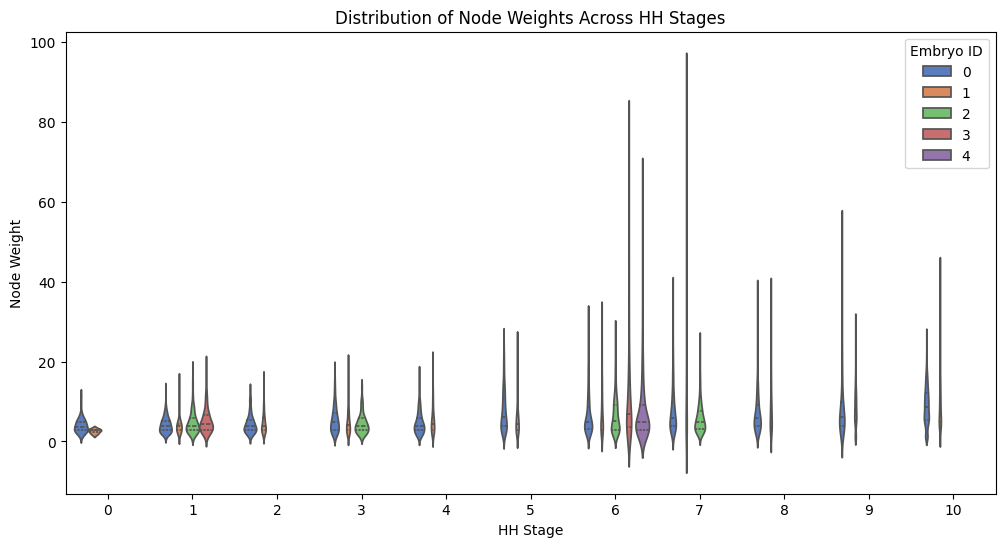

In [ ]:

import seaborn as sns
def violins(df,nodes_all_stages):
    # 1. Create an empty list to hold all our individual dataframes
    all_dataframes = []

    # 2. Loop through every stage and every embryo
    for stage, embryos in enumerate(nodes_all_stages):
        for n, df in enumerate(embryos):
            
            # Make a copy so we don't accidentally modify your original data
            temp_df = df.copy()
            
            # 3. Add the metadata as new columns! 
            # This is the crucial step for Seaborn so it knows where each node came from.
            temp_df['HH Stage'] = stage
            temp_df['Embryo ID'] = n
            
            # Append this updated dataframe to our list
            all_dataframes.append(temp_df)

    # 4. Mash them all together into one giant DataFrame
    # ignore_index=True ensures we get a fresh set of row numbers from 0 to N
    flat_df = pd.concat(all_dataframes, ignore_index=True)

    # Let's verify it worked
    print(flat_df[['HH Stage', 'Embryo ID', 'weight']].head())



    plt.figure(figsize=(12, 6))

    # Plot the full distribution of node weights per stage
    sns.violinplot(
        data=flat_df, 
        x='HH Stage', 
        y='weight',          # Make sure this exactly matches your column name
        hue='Embryo ID',     # Optional: Splits the violins to show each embryo side-by-side
        palette='muted',
        inner='quartile'
    )

    plt.title('Distribution of Node Weights Across HH Stages')
    plt.ylabel('Node Weight')
    plt.xlabel('HH Stage')
    plt.show()

violins(df,nodes_all_stages)

In [9]:
no_drug_df=pickle.load(open(f"results/skeleton/main_results/df_features_all_n.txt","rb"))
hh13_means = no_drug_df.loc[:,(13,)].mean(axis=1)
hh11_means = no_drug_df.loc[:,(11,)].mean(axis=1)
hh8_means = no_drug_df.loc[:,(8,)].mean(axis=1)

In [10]:
def plot_feature(feature,df,conditions,drug_name,means,means_label):
    # get the specific feature and drop any missing embryos (the nans)
    plt.figure(figsize=(8, 5))
    plt.scatter(conditions, df.loc[feature], alpha=0.7, edgecolors='black')
    #plt.plot(stages,means,linewidth=3)

    plt.xlabel("Drug Condition")
    if feature== "Mean Edge Length":
        plt.ylabel(f"{feature} in Microns")
    else:
        plt.ylabel(feature)

    plt.axhline(means[feature],label=f"{means_label} mean (no drugs)")
    plt.legend()
    plt.title(f"{drug_name}: {feature} per Embryo")
    #plt.xticks(stages) # Ensures your X-axis only shows the actual stage numbers
    plt.ylim(bottom=0)

    plt.show()

control nuclei    3583
10um nuclei       3197
20um nuclei       2568
Name: Number of Nodes, dtype: object


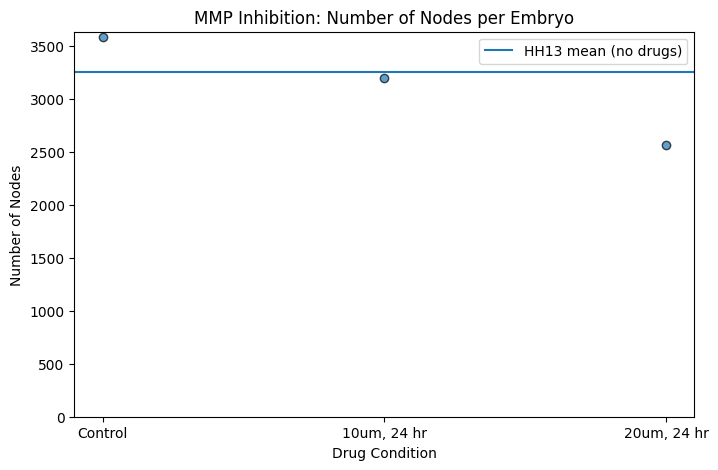

control nuclei    116.641767
10um nuclei        99.214045
20um nuclei         91.71958
Name: Mean Edge Length, dtype: object


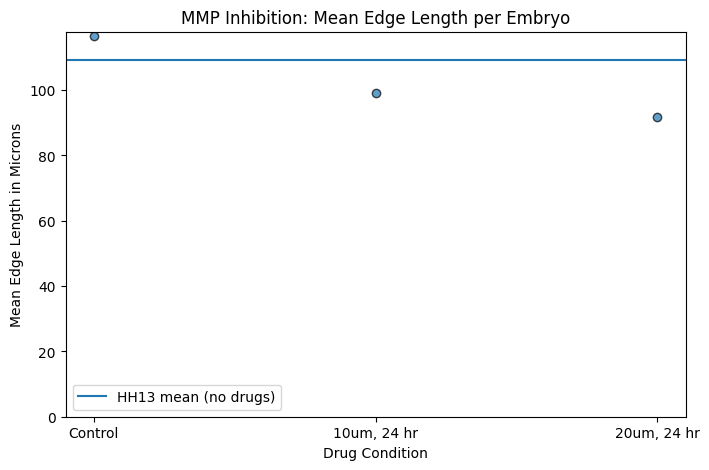

control nuclei    8.821684
10um nuclei       7.292384
20um nuclei       7.579671
Name: Mean Node Weight, dtype: object


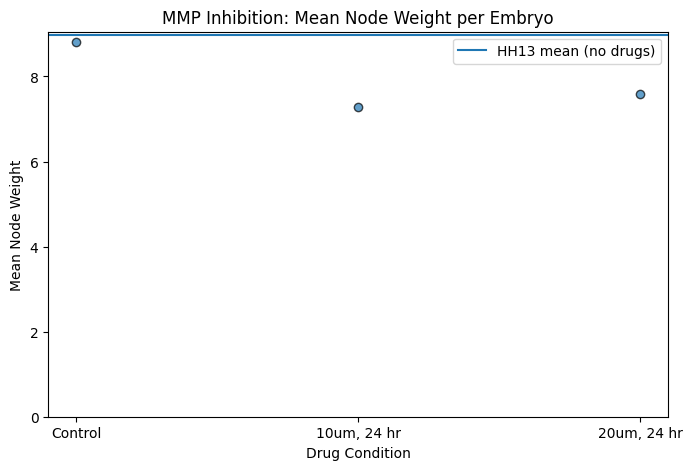

control nuclei    1.978436
10um nuclei       1.834418
20um nuclei       1.816302
Name: Average Degree of Non-Isolated Nodes, dtype: object


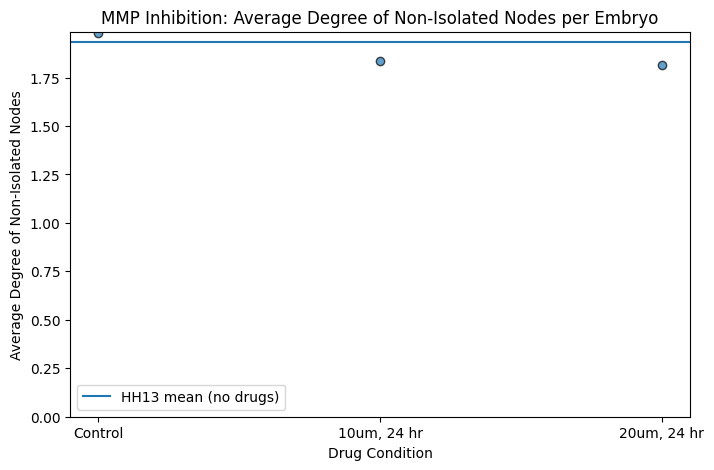

control nuclei    283
10um nuclei       160
20um nuclei       112
Name: Number of Basis Cycles, dtype: object


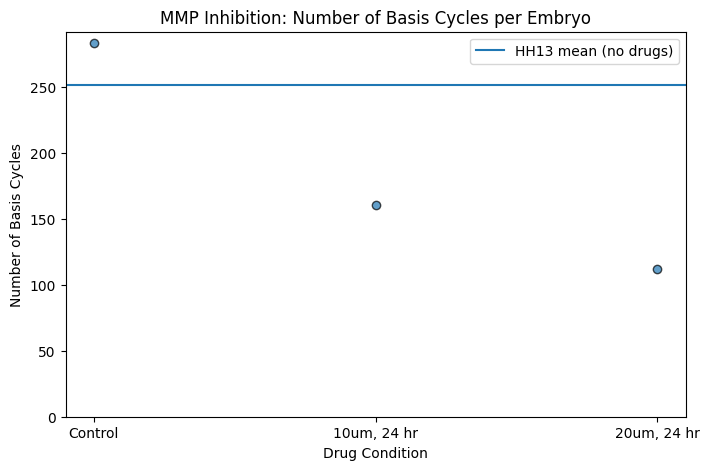

control nuclei    419
10um nuclei       532
20um nuclei       436
Name: Number of Components, dtype: object


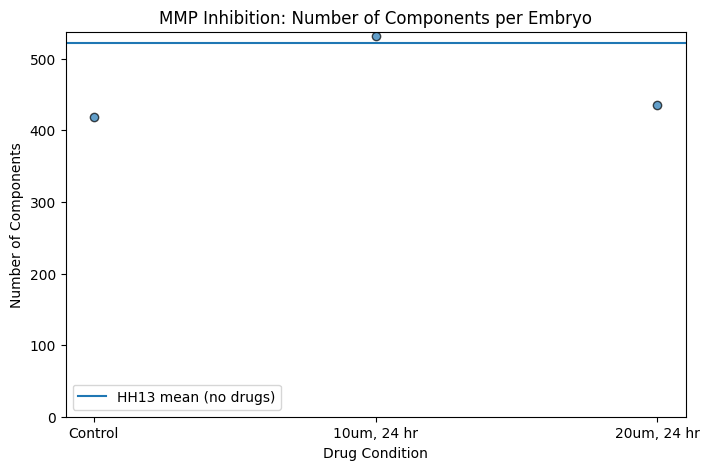

control nuclei    0.024933
10um nuclei       0.020269
20um nuclei       0.018692
Name: Average Clustering, dtype: object


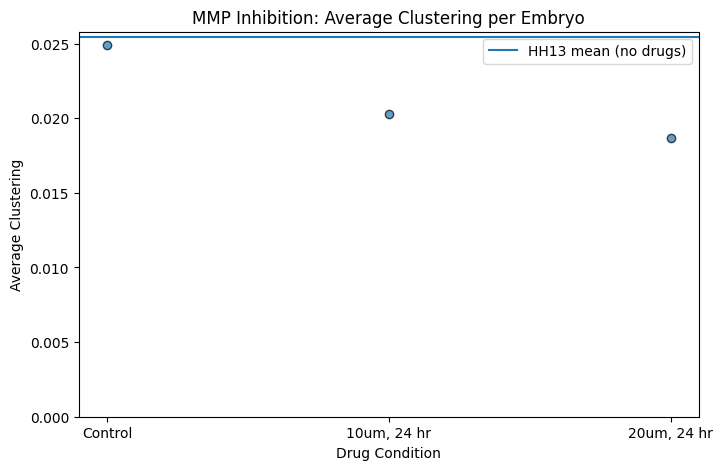

control nuclei    4137.216548
10um nuclei       3633.786209
20um nuclei        1822.31402
Name: Average Shortest Path, dtype: object


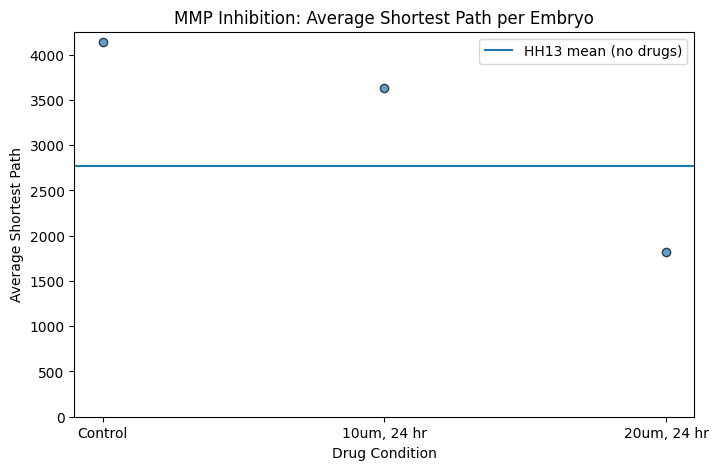

control nuclei    105
10um nuclei       123
20um nuclei       102
Name: Number of Isolated Nodes, dtype: object


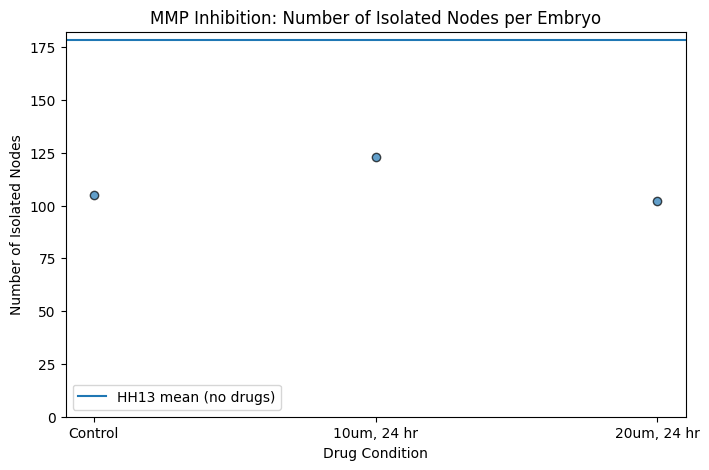

control nuclei    314
10um nuclei       409
20um nuclei       334
Name: Number of Components, Excluding Isolated Nodes, dtype: object


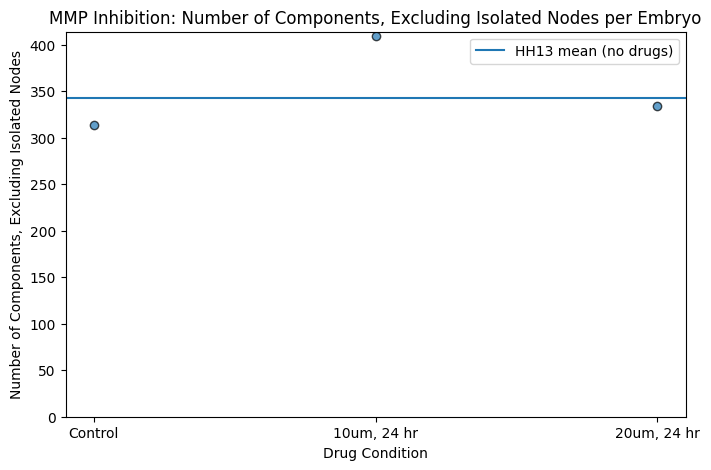

control nuclei    0.029305
10um nuclei       0.038474
20um nuclei        0.03972
Name: Proportion of Isolated Nodes, dtype: object


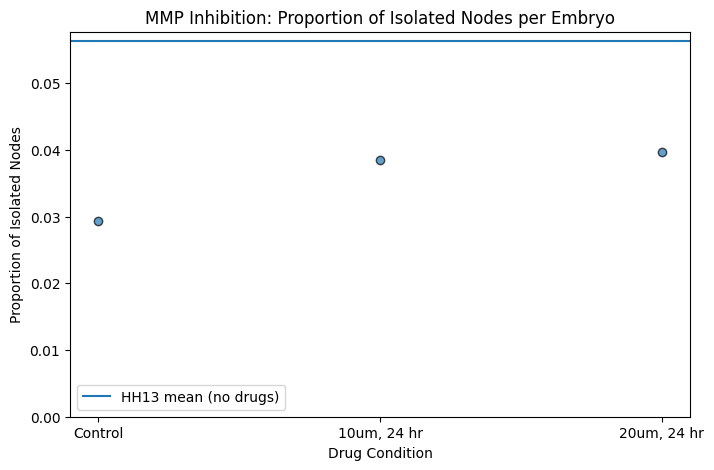

In [11]:
x_label = ["Control", "10um, 24 hr", "20um, 24 hr"]
#print(df.loc["Number of Nodes"])
for i in properties:
    print(df.loc[i])
    plot_feature(i,df,x_label,"MMP Inhibition",hh13_means,"HH13")

control nuclei    3583
10um nuclei       3197
20um nuclei       2568
Name: Number of Nodes, dtype: object


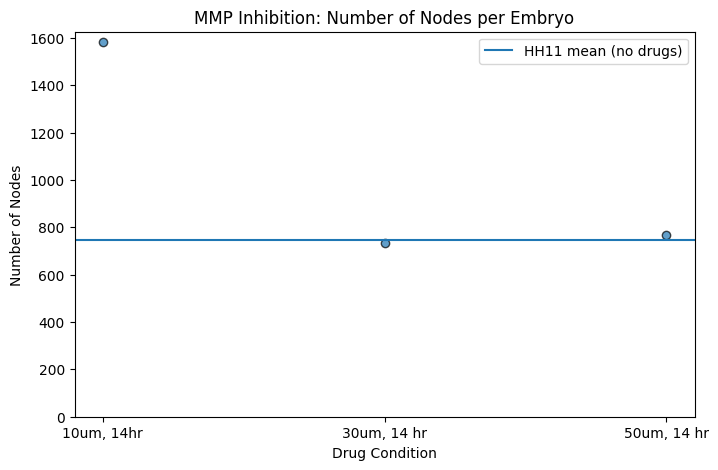

control nuclei    116.641767
10um nuclei        99.214045
20um nuclei         91.71958
Name: Mean Edge Length, dtype: object


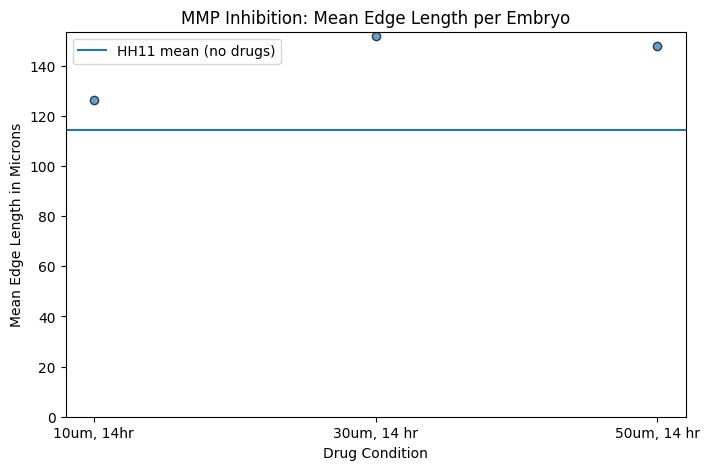

control nuclei    8.821684
10um nuclei       7.292384
20um nuclei       7.579671
Name: Mean Node Weight, dtype: object


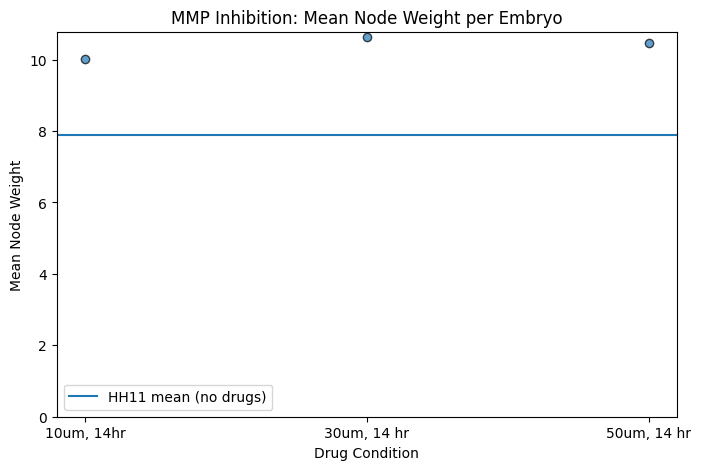

control nuclei    1.978436
10um nuclei       1.834418
20um nuclei       1.816302
Name: Average Degree of Non-Isolated Nodes, dtype: object


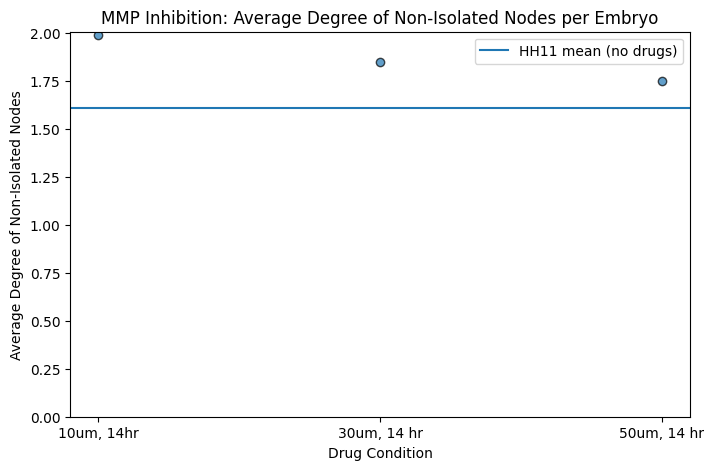

control nuclei    283
10um nuclei       160
20um nuclei       112
Name: Number of Basis Cycles, dtype: object


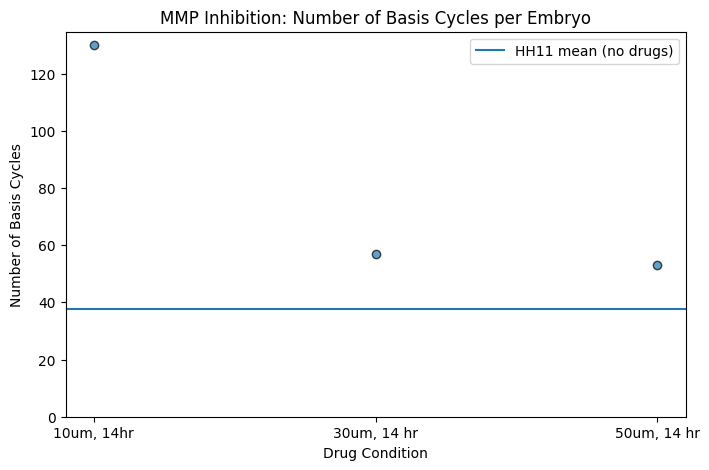

control nuclei    419
10um nuclei       532
20um nuclei       436
Name: Number of Components, dtype: object


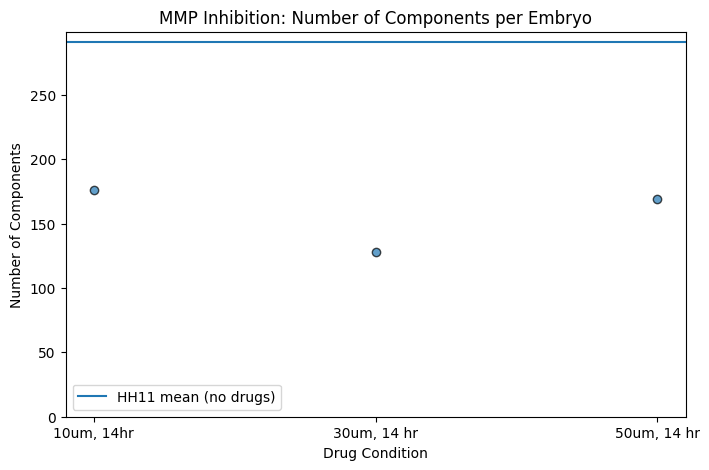

control nuclei    0.024933
10um nuclei       0.020269
20um nuclei       0.018692
Name: Average Clustering, dtype: object


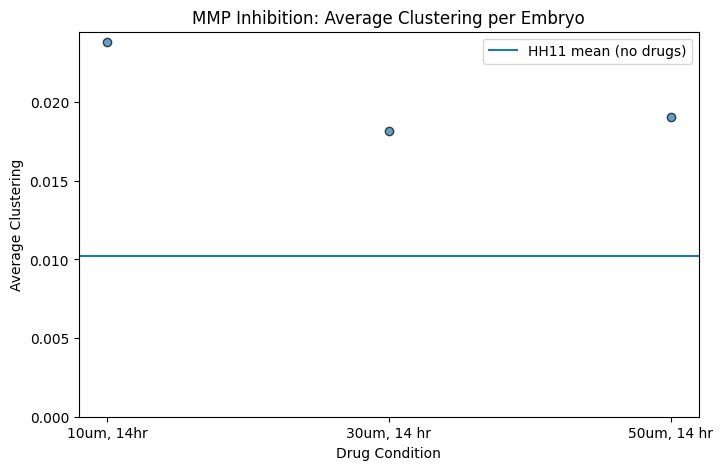

control nuclei    4137.216548
10um nuclei       3633.786209
20um nuclei        1822.31402
Name: Average Shortest Path, dtype: object


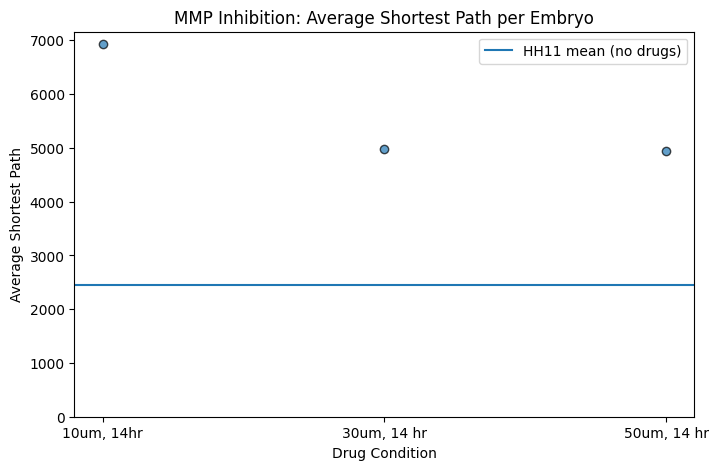

control nuclei    105
10um nuclei       123
20um nuclei       102
Name: Number of Isolated Nodes, dtype: object


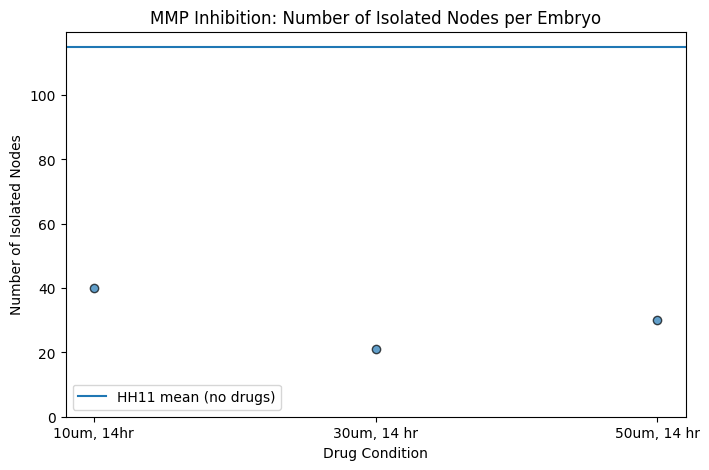

control nuclei    314
10um nuclei       409
20um nuclei       334
Name: Number of Components, Excluding Isolated Nodes, dtype: object


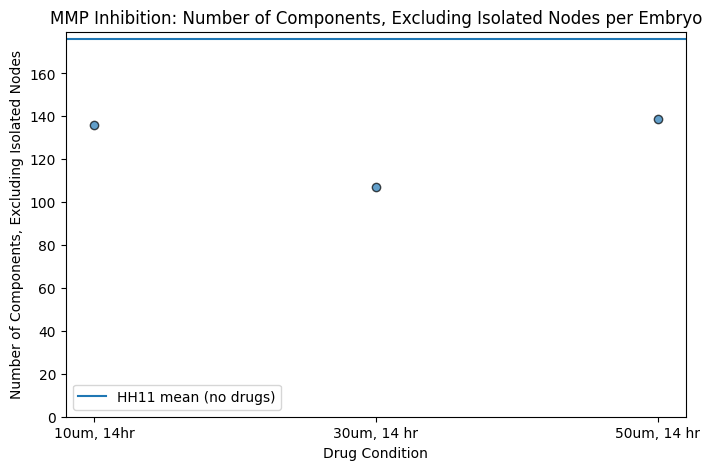

control nuclei    0.029305
10um nuclei       0.038474
20um nuclei        0.03972
Name: Proportion of Isolated Nodes, dtype: object


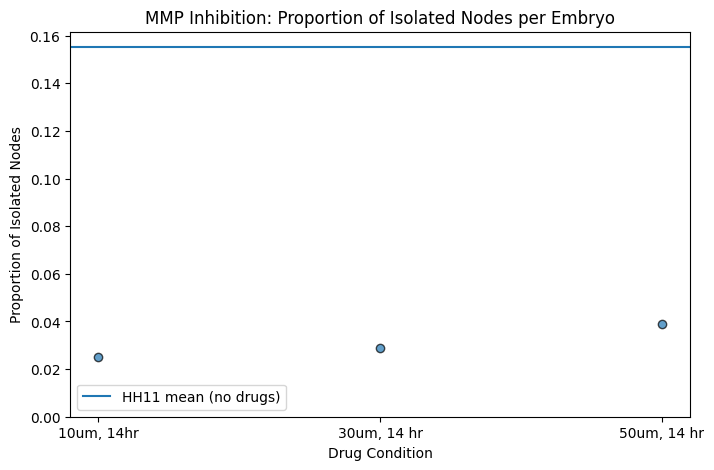

In [28]:
x_label = ["10um, 14hr", "30um, 14 hr", "50um, 14 hr"]
#print(df.loc["Number of Nodes"])
for i in properties:
    print(df.loc[i])
    plot_feature(i,df_brendan,x_label,"MMP Inhibition",hh11_means,"HH11")

['Control', '10um, 14hr', '10um, 24hr', '20um, 24hr', '30um, 14hr', '50um, 14hr']
                                               control nuclei         10um  \
Number of Nodes                                          3583         1583   
Mean Edge Length                                   116.641767   126.296514   
Mean Node Weight                                     8.821684    10.017187   
Average Degree of Non-Isolated Nodes                 1.978436     1.988983   
Number of Basis Cycles                                    283          130   
Number of Components                                      419          176   
Average Clustering                                   0.024933     0.023794   
Average Shortest Path                             4137.216548  6934.937738   
Number of Isolated Nodes                                  105           40   
Number of Components, Excluding Isolated Nodes            314          136   
Proportion of Isolated Nodes                         0.02930

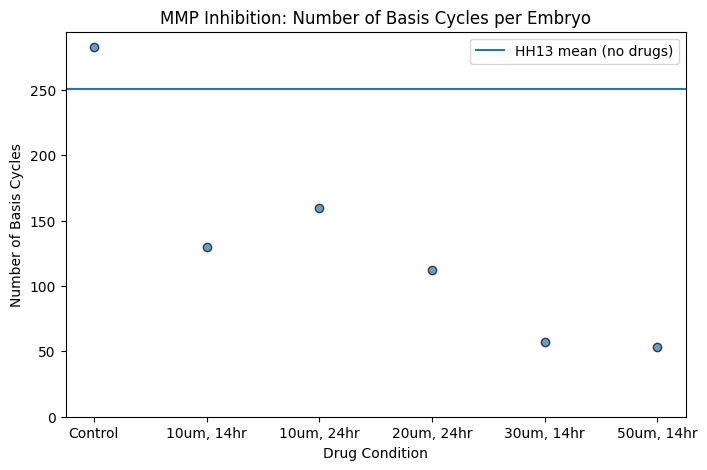

In [21]:
x_label = ["10um, 14hr", "30um, 14 hr", "50um, 14 hr", "Control", "10um, 24 hr", "20um, 24 hr"]
x_label = ["Control","10um, 14hr","10um, 24hr","20um, 24hr","30um, 14hr","50um, 14hr"]
both_df = pd.concat([df,df_brendan],axis=1)
both_df = both_df.loc[:, ["control nuclei","10um","10um nuclei","20um nuclei","30um","50um"]]

print(x_label)
print(both_df)

plot_feature("Number of Basis Cycles",both_df,x_label,"MMP Inhibition",hh13_means,"HH13")

In [12]:
def calc_degrees(adj,nodes):
    neighbours = adj.count()
    nodes["degree"] = neighbours
    return nodes

In [13]:
def calc_dists(adj,nodes):
    dists = adj.mean()
    nodes["distances"] = dists
    return nodes

In [14]:
#specify input image
stage=13
stage_id = stages.index(stage)
n=2

path = f"data/skeleton/all/"  
image = cv2.imread(f'{path}n{n}_hh{stage}_skeleton.jpg')
height = len(image)
width = len(image[0])
nodes = nodes_all_stages[stage_id][n-1]
adj = adj_all_stages[stage_id][n-1]

#append the degree data
nodes = calc_degrees(adj,nodes)


plt.figure(figsize=(8, 6))
# c='degree' maps the color to the feature, cmap is the color scheme
scatter = plt.scatter(nodes['x'], height-nodes['y'], c=nodes['degree'], cmap='viridis', s=10)
plt.colorbar(scatter, label='Number of Neighbors (Degree)')
plt.title(f'Connectivity of a HH{stage} Embryo')
plt.show()

TypeError: object of type 'NoneType' has no len()

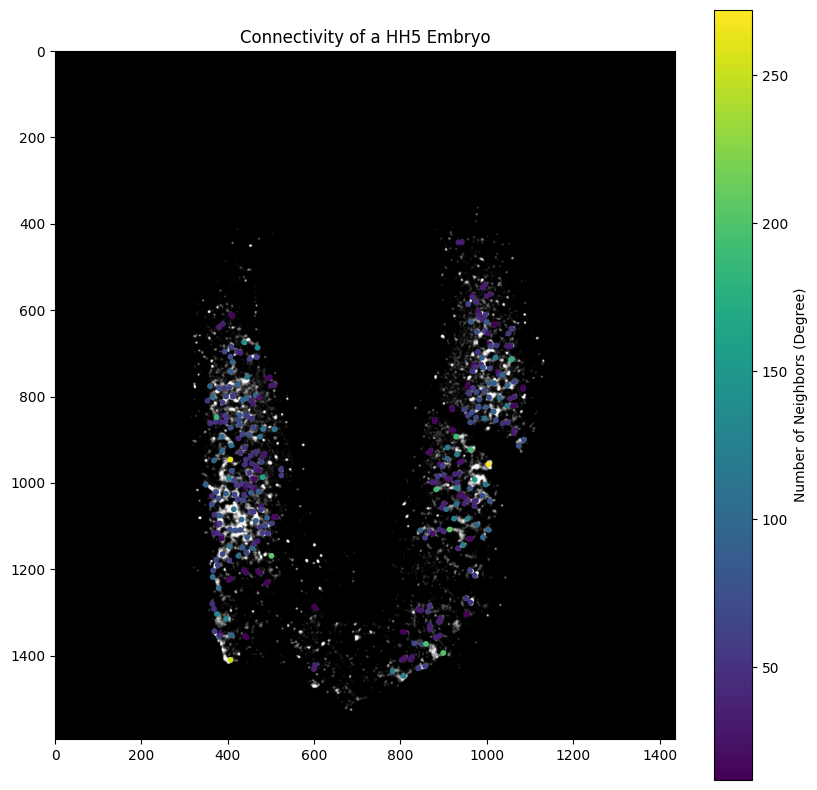

: 

In [ ]:
#specify input image
stage=5
stage_id = stages.index(stage)
n=2

path = f"data/skeleton/all/"  
image = cv2.imread(f'{path}n{n}_hh{stage}_plain_scaled.jpg')
height = len(image)
width = len(image[0])
nodes = nodes_all_stages[stage_id][n-1]
adj = adj_all_stages[stage_id][n-1]

#append the degree data
nodes = calc_dists(adj,nodes)



x_max,y_max = x_min+size,y_min+size

fig,ax=plt.subplots(figsize=(10,10))
# c='degree' maps the color to the feature, cmap is the color scheme
scatter = plt.scatter(nodes['x'], nodes['y'], c=nodes['distances'], cmap='viridis', s=10)
fig.colorbar(scatter, label='Number of Neighbors (Degree)')
ax.imshow(image, cmap=plt.cm.gray)
ax.set_title(f'Connectivity of a HH{stage} Embryo')

plt.show()

In [ ]:
def gen_pyvis_graph(nodes,adj,name):
    G = Network(height="750px", width="100%", bgcolor="#1F1F1F", font_color="white",notebook=True)
    G.toggle_physics(False)
    for i in nodes.index:
        node = nodes.loc[i]
        G.add_node(i,label=i,size=float(node["weight"])/50,x=int(node["x"]),y=int(node["y"]))
        #G.add_nodes_from([(i, {"x": int(node["x"]), "y": int(node["y"]), "weight":float(node["weight"])})])
    for i in adj.index:
        for j in adj.columns:
            edge_weight = adj.loc[i,j]
            if edge_weight>0:
                G.add_edge(i,j,weight=float(edge_weight))
                if i==j:
                    print(f"edge between {i} and {j}")
    #nx.draw(G, with_labels=True)
    G.show(f"{name}")#,notebook=True)
    return G

: 

In [ ]:
stage = 6
n = 0

stage_id = stages.index(stage)


nodes = nodes_all_stages[stage_id][n]
adj = adj_all_stages[stage_id][n]


gen_pyvis_graph(nodes,adj,f"results/skeleton/hh{stages[stage_id]}_skeletonisation.html")

Local cdn resources have problems on chrome/safari when used in jupyter-notebook. 
edge between 95 and 95


<class 'pyvis.network.Network'> |N|=424 |E|=249

: 